In [287]:
import os
import joblib
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import re
from deep_translator import GoogleTranslator
from skopt.space import Categorical, Integer, Real
from skopt import BayesSearchCV
from langdetect import detect
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion

In [288]:
import spacy

spacy.prefer_gpu()  # usa GPU si está disponible, si no sigue en CPU
nlp = spacy.load("es_core_news_sm")

In [289]:
texto_origen = pd.read_csv('data/train.csv', sep=',', encoding='utf-8')

In [290]:
data= texto_origen.copy()

In [291]:
data.shape

(31403, 2)

In [292]:
data.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


In [293]:
data.loc[0, 'text']

'\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nlib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19 '

In [294]:
data.isna().sum()

text      0
decade    0
dtype: int64

In [295]:
num_decadas=data['decade'].value_counts()
num_decadas

decade
160    848
172    842
155    836
170    833
178    831
167    831
154    830
157    827
163    827
180    825
168    822
175    817
171    816
165    814
151    812
179    809
188    809
162    808
182    808
174    807
164    804
185    803
184    802
173    802
159    802
181    795
183    794
156    792
161    787
187    787
150    786
152    785
177    782
166    779
158    778
153    775
186    773
169    771
176    754
Name: count, dtype: int64

In [296]:
num_decadas.shape

(39,)

In [297]:
data.duplicated().sum()

34

In [298]:
duplicados = data[data.duplicated(keep=False)].sort_values(by='text')
duplicados

,text,decade
24120,"\nEarly European Books, Copyright© 201 1 ...",155
8630,"\nEarly European Books, Copyright© 201 1 ...",155
28761,"\nEarly European Books, Copyright© 201 1 ...",155
250,"\nEarly European Books, Copyright© 201 1 ...",158
20681,"\nEarly European Books, Copyright© 201 1 ...",158
...,...,...
28408,froduce los produflos AB. y BC. tendrán ...,171
19050,s]2lltaniccloquéda.ii\a.Dcon-o íftruméto cardc...,151
23916,s]2lltaniccloquéda.ii\a.Dcon-o íftruméto cardc...,151
20346,tentia Paul.de Caft.in.d.l.fi. C. commu.de leg...,151


In [299]:
# Duplicados de texto pero con diferentes decadas

textos_conflictivos = (
    data.groupby('text')['decade']
    .nunique()
)
textos_conflictivos = textos_conflictivos[textos_conflictivos > 1].index

dup_distintas_decadas = (
    data[data['text'].isin(textos_conflictivos)]
    .sort_values(by='text')
)

print(f"Filas con texto duplicado en décadas distintas: {len(dup_distintas_decadas)}")
print(f"Textos únicos en conflicto: {len(textos_conflictivos)}")
dup_distintas_decadas


Filas con texto duplicado en décadas distintas: 29
Textos únicos en conflicto: 12


,text,decade
11320,+ Haga un uso exclusivamente no comercial de e...,183
6834,+ Haga un uso exclusivamente no comercial de e...,181
30705,"+ Keep it legal Whatever your use, remember th...",186
16203,"+ Keep it legal Whatever your use, remember th...",180
3382,"+ Keep it legal Whatever your use, remember th...",175
8174,"+ Maintain attribution The Google ""watermark"" ...",179
5840,"+ Maintain attribution The Google ""watermark"" ...",157
8989,+ Make non-commercial use of the files We desi...,162
5366,+ Make non-commercial use of the files We desi...,188
13141,+ Manténgase siempre dentro de la legalidad Se...,155


In [300]:
textos_conflictivos = data.groupby('text').filter(lambda g: g['decade'].nunique() > 1)
textos_conflictivos.sort_values(by='text')

,text,decade
11320,+ Haga un uso exclusivamente no comercial de e...,183
6834,+ Haga un uso exclusivamente no comercial de e...,181
30705,"+ Keep it legal Whatever your use, remember th...",186
16203,"+ Keep it legal Whatever your use, remember th...",180
3382,"+ Keep it legal Whatever your use, remember th...",175
8174,"+ Maintain attribution The Google ""watermark"" ...",179
5840,"+ Maintain attribution The Google ""watermark"" ...",157
8989,+ Make non-commercial use of the files We desi...,162
5366,+ Make non-commercial use of the files We desi...,188
13141,+ Manténgase siempre dentro de la legalidad Se...,155


In [301]:
patrones=data.copy()

<Axes: xlabel='num_palabras', ylabel='Count'>

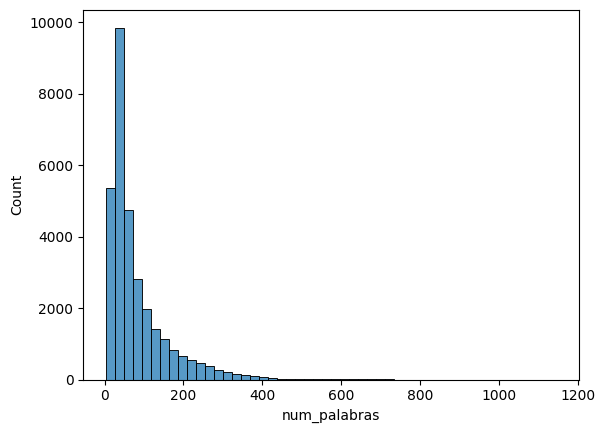

In [302]:
patrones['num_palabras'] = patrones['text'].apply(lambda x: len(x.split()))
patrones['num_palabras'].describe()
sns.histplot(patrones['num_palabras'], bins=50)

In [303]:
"""from langdetect import detect

def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return 'unknown'

patrones['idioma'] = patrones['text'].apply(lambda x: detectar_idioma(x) if len(x) > 20 else 'unknown')
patrones['idioma'].value_counts()"""

"from langdetect import detect\n\ndef detectar_idioma(texto):\n    try:\n        return detect(texto)\n    except:\n        return 'unknown'\n\npatrones['idioma'] = patrones['text'].apply(lambda x: detectar_idioma(x) if len(x) > 20 else 'unknown')\npatrones['idioma'].value_counts()"

# Limpieza Inicial
### Eliminación de Duplicados

In [304]:
data = data.drop_duplicates(keep='first')
data[data.duplicated()]

,text,decade


In [305]:
data = data[~data['text'].isin(dup_distintas_decadas['text'])]

In [306]:
dup_textos = data.groupby('text').filter(lambda g: g['decade'].nunique() > 1)
dup_textos.sort_values(by='text')

,text,decade


# Partición de los datos

In [307]:
target = 'decade'
X = data['text']
y= data[target]

In [308]:
X.head()

0    \nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...
1    gone. Sus amigos , sus clientes, todo \ncuanto...
2    Prefosen quemanera,e per qualesfolpechas deuan...
3    Caistro  el  M  a  y  o  r  a  i  .]  Del  ape...
4    \nlos  que  panden  macho  ;  y \notros  en  l...
Name: text, dtype: object

In [309]:
y.head()

0    164
1    182
2    157
3    163
4    166
Name: decade, dtype: int64

In [310]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [311]:
def normalizar_ortografia(texto):

    #Reducir la cantidad de formas diferentes de una misma palabra que el modelo tiene que aprender a asociar con la misma clase.
    #Sacado de los textos con errores que no predice bien el modelo
    texto = texto.str.replace("ſ", "s")   # s larga → s normal , coſa -> cosa lo puede ver como palabras distintas , aunque significan lo mismo
    texto = texto.str.replace("ç", "c")   # cedilla → c
    #texto = texto.replace("v","b")
    #texto = texto.replace("z","s")
    texto = texto.str.replace("æ","ae")
    texto = texto.str.replace("œ","oe")
    # variantes antiguas comunes (opcionales)
    #texto = texto.str.replace("ph", "f")   # philosophia → filosofia
    #texto = texto.str.replace("y", "i")    

    #texto = texto.str.replace("0","o")
    #texto = texto.str.replace("1","l")
    #texto = texto.str.replace("3","e")
    #texto = texto.str.replace("5","s")
    

    #texto = texto.str.replace("vv","w")
    #texto = texto.str.replace("ii","i")

    texto = texto.str.replace("ﬁ","fi")
    texto = texto.str.replace("ﬂ","fl")

    # errores OCR comunes en textos antiguos
    texto = texto.str.replace("noftri","nostri")
    texto = texto.str.replace("lefu","iesu")
    texto = texto.str.replace("chrifti","christi")
    texto = texto.str.replace("apoft","apost")
    texto = texto.str.replace("eccl","eccl")
    texto = texto.str.replace("cx","ex")
    

    texto = texto.str.replace(r"(.)\1{2,}", r"\1\1", regex=True) # Reemplaza secuencias de 3 o más caracteres repetidos por solo 2. 
                                                                 #Ejemplo: "loooool" -> "lool". No 1 porque llamar (dos caracteres seguidos)

    return texto

In [312]:
import re

def limpiar_texto(serie):
    def _limpiar_uno(texto):
        if not isinstance(texto, str):
            return ''
        # Unir palabras partidas por - o ¬ al final de línea (antes de quitar guiones)
        texto = re.sub(r'[-¬]\s*\n\s*', '', texto)
        # Minúsculas
        texto = texto.lower()
        # Eliminar saltos de línea y espacios múltiples
        texto = re.sub(r'\s+', ' ', texto)
        # Eliminar números
        texto = re.sub(r'\d+', '', texto)
        # Eliminar todo lo que no sea letra (con o sin acento) o espacio
        texto = re.sub(r'[^a-záéíóúüñàèìòùâêîôûäëïöça-z\s]', ' ', texto)
        # Colapsar espacios que quedaron
        texto = re.sub(r'\s+', ' ', texto)
        return texto.strip()
    return pd.Series(serie).apply(_limpiar_uno)

In [313]:
from deep_translator import GoogleTranslator
from langdetect import detect
from concurrent.futures import ThreadPoolExecutor

def traducir_si_no_es_español(texto):
    try:
        if detect(texto) != "es":
            return GoogleTranslator(source="auto", target="es").translate(texto)
        return texto
    except:
        return texto

def traducir(textos):
    with ThreadPoolExecutor(max_workers=6) as executor:
        return list(executor.map(traducir_si_no_es_español, textos))
    

In [314]:
from nltk.corpus import stopwords

STOPWORDS_ES = list(stopwords.words('spanish'))

In [315]:
def lematizar(serie):
    def _lematizar_uno(texto):
        if not isinstance(texto, str) or len(texto.strip()) == 0:
            return ''
        doc = nlp(texto)
        resultado = ' '.join([token.lemma_ for token in doc if not token.is_stop])
        return re.sub(r'\s+', ' ', resultado).strip()
    return pd.Series(serie).apply(_lematizar_uno)

In [316]:
# ── 1. Pre-procesar una sola vez ──────────────────────────────
X_train_proc = lematizar(traducir(limpiar_texto(normalizar_ortografia(pd.Series(X_train)))))
X_test_proc  = lematizar(traducir(limpiar_texto(normalizar_ortografia(pd.Series(X_test)))))

# Guardar para no repetir si se reinicia el kernel
pd.Series(X_train_proc).to_csv("data/X_train_procesado.csv", index=False)
pd.Series(X_test_proc).to_csv("data/X_test_procesado.csv",  index=False)

In [317]:
X_train_proc

0        xtension situación ci éese zaragoza tiempo sit...
1        fray fulgencio preguntar rey reina encontrar j...
2        angaripola plur dícese adomoa afédado color so...
3        ce majoy fu majdad eneleícje fiafticofe dizein...
4        tsddiiqópottitimeícquirar great triíhtia rcórn...
                               ...                        
25067    ojficul deutn ejlar yunf cr rf í entrt tr ro p...
25068    devuelta diputación á cámara insistir ser gene...
25069    lector recordar ardor inglés abrazar negociaci...
25070    fo cutdíi efo ímia vna trn bmn m preguntar k c...
25071    mañana volver nuevamente fuego inedia lún izqu...
Length: 25072, dtype: object

In [318]:
features = FeatureUnion([
    ('word', TfidfVectorizer(
        analyzer='word',
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        stop_words=STOPWORDS_ES
    )),
    ('char', TfidfVectorizer(
        analyzer='char_wb',  # char n-grams dentro de palabras
        max_features=30000,
        ngram_range=(3, 5),  # trigramas a pentagramas de caracteres
        min_df=2,
        sublinear_tf=True
    ))
])

In [319]:
pipeline = Pipeline(steps=[
    ('features', features),
    ('model', LinearSVC(random_state=42, max_iter=2000))
])


In [ ]:
param_grid = {
    'model__C': [0.1, 1.0, 10.0],
}


In [321]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [322]:
decision_bayes = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)

In [323]:
decision_bayes.fit(X_train_proc, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('features',
                                        FeatureUnion(transformer_list=[('word',
                                                                        TfidfVectorizer(max_features=30000,
                                                                                        min_df=2,
                                                                                        ngram_range=(1,
                                                                                                     2),
                                                                                        stop_words=['de',
                                                                                                    'la',
                                                                                                    'que',
                                                                                                    'el',
                                                                                                    'en',
                                                                                                    'y',
                                                                                                    'a',
                                                                                                    'los',
                                                                                                    'del',
                                                                                                    'se',
                                                                                                    'las',
                                                                                                    'por',
                                                                                                    'un',
                                                                                                    'para',
                                                                                                    'con',
                                                                                                    'no',
                                                                                                    'una',
                                                                                                    'su',
                                                                                                    'al',
                                                                                                    'lo',
                                                                                                    'como',
                                                                                                    'más',
                                                                                                    'pero',
                                                                                                    'sus',
                                                                                                    'le',
                                                                                                    'ya',
                                                                                                    'o',
                                                                                                    'este',
                                                                                                    'sí',
                                                                                                    'porque', ...],
                                                                                        sublinear_tf=True)),
                                                                       ('c

In [324]:
# ── 5. Evaluar ────────────────────────────────────────────────
print('Mejores hiperparámetros:\n')
display(decision_bayes.best_params_)
print(f'\nMejor puntaje CV: {decision_bayes.best_score_:.3f}')

best_model = decision_bayes.best_estimator_
y_pred = best_model.predict(X_test_proc)
print(classification_report(y_test, y_pred))

Mejores hiperparámetros:



{'model__C': 0.1}


Mejor puntaje CV: 0.211
              precision    recall  f1-score   support

         150       0.52      0.76      0.62       152
         151       0.41      0.69      0.51       159
         152       0.49      0.54      0.51       186
         153       0.48      0.57      0.52       157
         154       0.41      0.58      0.48       173
         155       0.24      0.20      0.22       163
         156       0.35      0.43      0.39       161
         157       0.17      0.18      0.17       154
         158       0.21      0.23      0.22       161
         159       0.24      0.22      0.23       166
         160       0.07      0.07      0.07       161
         161       0.08      0.05      0.06       167
         162       0.20      0.22      0.21       156
         163       0.17      0.10      0.13       185
         164       0.19      0.16      0.18       152
         165       0.11      0.11      0.11       150
         166       0.09      0.05      0.06       142
  

In [325]:
best_model = decision_bayes.best_estimator_